## TP5 - Michel Jean Joseph Donnet

In [1]:
## imports
import csv
import numpy as np
import matplotlib.pyplot as plt

### PART 1 - Monday, November 14, 2022

In [2]:
with open('data/X.dat', newline='') as f:
    reader = csv.reader(f, quoting=csv.QUOTE_NONNUMERIC)
    X_dat = list(reader)
with open('data/Y.dat', newline='') as f:
    reader = csv.reader(f, quoting=csv.QUOTE_NONNUMERIC)
    Y_dat = list(reader)

## 2D array of shape (200, 400), each row (image) contains the 400 grey values of each image
X = np.array(X_dat).reshape(200, 400)
## list of 200 labels, label for each image, 1 if image is '2' and 0 if image is '3'
y_k = [y[0] for y in Y_dat]

In [3]:
## NOTE : HELPER FUNCTION, IF NEEDED
# Checks if all elements of a list are equal
def checkEqual(lst):
    '''
    checks if all elements of a list are equal
    (by checking if the count of the first element is equal to the list length)

    Parameters:
    -----------
    lst : list of x elements

    Returns:
    --------
    True if all x elements of the list are equal, and False otherwise
    '''
    return lst.count(lst[0]) == len(lst)

In [41]:
# Sigmoidal function
def fun_sigmoid(x):
    # TODO
    '''
    compute sigmoid of value x

    Parameters:
    -----------
    x : scalar value

    Returns:
    --------
    sigmoid(x)
    '''
    return 1.0 / (1.0 + np.exp(-x))


# Calculate h-w1-w2
def h12(pso, X):
    # TODO
    '''
    calculate state of activation of the output layer of neurons (list of 200 values, a value for each image)

    Parameters:
    -----------
    pso : position vector of one particle
    X : 2D array of shape (200, 400), each row (image) contains the 400 grey values of each image

    Returns:
    --------
    h : list of 200 values representing the state of activation of the output layer of neurons
    '''
    # w2 matrix, (1, 26) of last 26 elements of pso
    # TODO
    w2 = pso[-26:].reshape(1, 26).astype(float)

    # w1 matrix (25, 401) of first 25*401 elements of pso
    # TODO
    w1 = pso[:-26].reshape(25, 401).astype(float)

    # results' list containing h value for each image
    results = []
    # for every image x
    for x in X:
        # get image (& copy !!)
        # TODO
        img = x.copy()
        # add 1 at 0-position
        # TODO
        img = np.concat([[1.0], img]).astype(float)
        # reshape
        # TODO
        img = img.reshape(-1, 1)
        # calculate c = matrix multiplication of weight matrix 1 and image vector(with 1 at position 0)
        # TODO
        c = w1 @ img
        # apply sigmoidal function on elements of c
        # TODO
        c = fun_sigmoid(c)
        # add 1 at 0-position
        # TODO
        c = np.concat([[1.0], c.ravel()]).astype(float)
        # reshape
        # TODO
        c = c.reshape(26, 1)
        # calculate matrix multiplication of weight matrix 2 and vector z(with 1 at position 0), answer is scalar
        # TODO
        scalar = (w2 @ c)[0, 0]
        # apply sigmoidal fucntion on answer
        # TODO
        scalar = fun_sigmoid(scalar)
        # results, append all h12 for all images
        # TODO
        results.append(scalar)

    return results


# Calculate overall fitness J
def calculate_J(h, y_k):
    # TODO
    '''
    calculate overall fitness J (equation #5 in TP PDF)

    Parameters:
    -----------
    h : list of 200 values representing the state of activation of the output layer of neurons
    y_k : list of 200 labels '1' or '0', for each image

    Returns:
    --------
    fitness_J : overall fitness, mean of all J for each image
    '''
    return np.mean((np.array(y_k).astype(float) - h)**2)

# prediction accuracy of images
def pred_acc(h, X, y_k):
    # TODO
    '''
    calculate the prediction accuracy (%) by comparing prediction & true labels
    y_p (predicted label) = 1 if h>=0.5 & 0 otherwise

    Parameters:
    -----------
    h : list of 200 values representing the state of activation of the output layer of neurons (to be used for best h12)
    X : 2D array of shape (200, 400), each row (image) contains the 400 grey values of each image
    y_k : list of 200 labels '1' or '0', for each image

    Returns:
    --------
    acc : prediction accuracy
    '''

    # get predicted labels
    # TODO
    h = np.array(h)
    y_k = np.array(y_k)
    y_p = np.ones_like(y_k)
    y_p[h < 0.5] = 0
    # get prediction accuracy (%)
    # TODO
    return (1 / y_k.shape[0]) * np.sum(y_k == y_p)


In [5]:
# Algorithm, and training the network
def pso_NN(X, y_k, N, vmax_coeff):
    # TODO
    '''
    perfom PSO algorithm with NN training

    Parameters:
    -----------
    X : 2D array of shape (200, 400), each row (image) contains the 400 grey values of each image
    y_k : list of 200 labels '1' or '0', for each image
    N : number of particles
    vmax_coeff : velocity cutoff coefficient (% of coordinates range, for eg: vmax_coeff=0.1 means vmax=0.1*(xmax_coordinate-xmin_coordinate))

    Returns:
    --------
    J_g : global best fitness
    b_g : global best position
    h_g : global best state activation of output neurons (needed later for prediction)
    J_global : list of all global best positions (for each iteration, needed to plot later on)
    '''
    ## Fixed Parameters
    # cognitive & social parameters
    c1 = c2 = 2
    # inertia constant
    w = 0.9
    # number of coefficients 'n' of weight matrices 1 & 2, combined (go back to h12 function for a reminder if needed)
    n = 401 * 25 + 26
    
    ## Variate Parameters
    # coordinates' range
    c_range = [-1, 1] # or [-0.5, 0.5]
    # velocity threshold vmax = vmax_coeff*(c_max - c_min)
    # TODO
    vmax = vmax_coeff*(np.max(c_range) - np.min(c_range))

    ## NOTE : STOPPING CONDITION
    # choose one of these two stopping conditions: 
    # 1. number of iterations, tmax=?
    # 2. last _ fitness values are equal (or not improving?)
    
    ## Initialize
    # initialize 's' : np array of size (N=number of particles, n=number of coefficients of weight matrices 1&2) with values from coefficients ranging in c_range
    # TODO
    s = np.random.uniform(low=c_range[0], high=c_range[1], size=(N, n))
    # initialize 'v' : np array of size(N, n) of velocity vectors of values 0
    # TODO
    v = np.zeros_like(s)
    
    ## Compute Initial J
    # Compute h12 for all pso in s
    # TODO
    h12_list = np.array([h12(pso, X) for pso in s])
    # compute and save J for all particles
    # TODO
    J_list = np.array([calculate_J(h, y_k) for h in h12_list])
    # get minimum J, and idx (index of minimum)
    # TODO
    idx = np.argmin(J_list)
    J_min = J_list[idx]
    # set local & global J (local J is best J for each particle, global J is best overall J)
    # TODO
    J_g = J_min
    J_global = [J_min]
    J_local = J_list.copy()
    # set local & global positions (local position is best b for each particle, global position is best overall b)
    b_g = s[idx].copy()
    b_local = s.copy()
    # TODO (don't forget to copy if needed !)
    # save minimum h12
    # TODO
    h_g = h12_list[idx]
    
    ## Run algorithm

    # STOPPING CONDITION
    # TODO
    t = 0
    tmax = 200
    while(t < tmax):
        ## For every particle position in s:
        for i in range(s.shape[0]):
            # r1, r2 random numbers between 0 & 1
            r1, r2 = np.random.uniform(low=0, high=1, size=2)
            # Update v
            v[i] = (w * v[i]
                 + c1 * r1 * (b_local[i] - s[i])
                 + c2 * r2 * (b_g - s[i])
            )
            # Check velocity if crossing upper/lower threshold
            v[i] = np.clip(v[i], min=-vmax, max=vmax)
            # Update position
            s[i] += v[i]
            # Check boundary condition & decide what to do if a particle crosses a boundary, some options are:
                # set crossing position to the boundary position
                # reflect crossing position
                # bounce-back crossing position
            bound_length = c_range[1] - c_range[0]
            # s[i] += c_range[0]
            # s[i] %= bound_length
            # s[i] -= c_range[0]
            s[i] = np.clip(s[i], min=c_range[0], max=c_range[1])
            # Calculate new J (by first calculating h12)
            h12_list[i] = h12(s[i], X)
            J_list[i] = calculate_J(h12_list[i], y_k)
            # Check if found new best fitness, set to local fitness
            if J_list[i] < J_local[i]:
                J_local[i] = J_list[i]
                b_local[i] = s[i].copy()
        # Get minimum of all new best J, if best is < global J, set to global J
        idx = np.argmin(J_local)
        if J_local[idx] < J_g:
            J_g = J_local[idx]
            b_g = s[idx].copy()
            # save best h12
            h_g = h12_list[idx].copy()
        J_global.append(J_g)
        t += 1
        # Update if Stopping Condition #2

    return J_g, b_g, h_g, J_global

0.023218543314954466
[np.float64(0.2309679477355474), np.float64(0.2309679477355474), np.float64(0.2309679477355474), np.float64(0.2309679477355474), np.float64(0.20860471233948719), np.float64(0.2052066284330816), np.float64(0.2045796680831879), np.float64(0.2014082489212253), np.float64(0.18882138460768527), np.float64(0.17912418830294535), np.float64(0.17912418830294535), np.float64(0.16849539716652737), np.float64(0.1549307000752251), np.float64(0.14850038273833438), np.float64(0.1432995406611713), np.float64(0.1432995406611713), np.float64(0.13784162760305055), np.float64(0.1288343350419874), np.float64(0.12191239308817298), np.float64(0.12081783499358462), np.float64(0.11531509131839066), np.float64(0.11220731858027705), np.float64(0.10994031907948486), np.float64(0.10662259052855108), np.float64(0.10504930167232825), np.float64(0.10425639950378734), np.float64(0.10304585085802107), np.float64(0.10041842171148478), np.float64(0.09994939059365962), np.float64(0.09708301907935205),

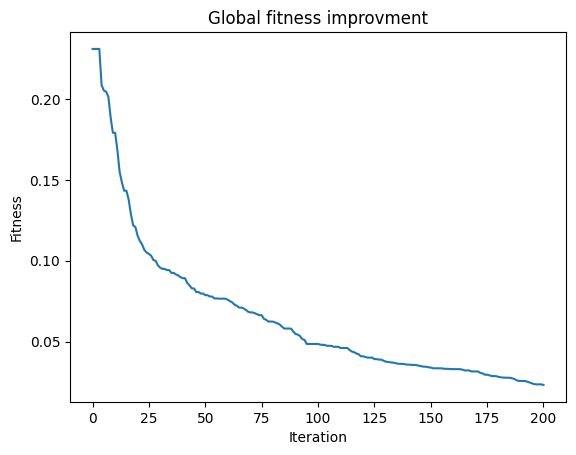

In [ ]:
# Test run pso_NN function for N=10 & vmax_coeff=0.1, and get prediction accuracy
# TODO
J_g, b_g, h_g, J_global = pso_NN(X, y_k, 10, 0.1)
plt.figure()
plt.plot(np.arange(len(J_global)), J_global)
plt.title("Global fitness improvment")
plt.xlabel("Iteration")
plt.ylabel("Fitness")
plt.show()

### PART 2 - Monday, November 21, 2022

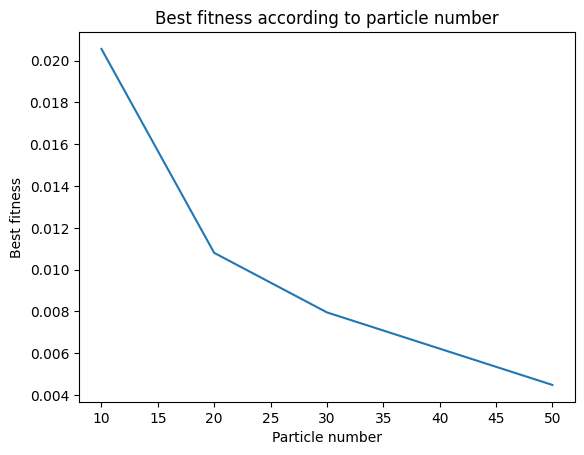

In [12]:
# Run algorithm for range of N, & plot best_fitness vs N (set vmax_coeff=0.1)
N = [10, 20, 30, 50]
result = []

for n in N:
    J_g, b_g, h_g, J_global = pso_NN(X, y_k, n, 0.1)
    result.append(J_g)
plt.figure()
plt.plot(N, result)
plt.title("Best fitness according to particle number")
plt.xlabel("Particle number")
plt.ylabel("Best fitness")
plt.show()

### How does the number of particles affect the result of the PSO algorithm?

As we can see on the graph, the more particle we have, the more our fitness decrease.
However, we can constate that the curve follow an exponential decay progression: improvement of fitness is notable between 10 and 20 particles, but between 30 and 50, there is no big improvement.
So the choice of N make the balance between precision and computation time.

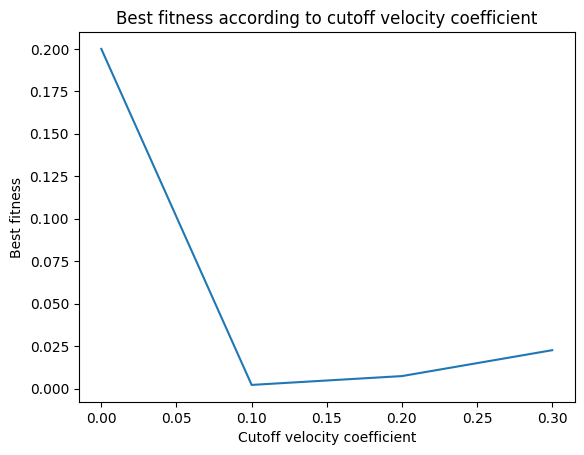

In [21]:
# Run algorithm for range of vmax_coeff, the cutoff velocity coefficient (choose N according to experiment above)
vmax_coeff = [0, 0.1, 0.2, 0.3]
result = []
for v in vmax_coeff:
    J_g, b_g, h_g, J_global = pso_NN(X, y_k, 50, v)
    result.append(J_g)
plt.figure()
plt.plot(vmax_coeff, result)
plt.title("Best fitness according to cutoff velocity coefficient")
plt.xlabel("Cutoff velocity coefficient")
plt.ylabel("Best fitness")
plt.show()

### How does the velocity cut-off $v_{max}$ affect the result of the PSO algorithm?

The the velocity cut-off $v_{max}$ determines how much the particles can move.

We can easily see on the plot that the velocity cut-off has a huge impact on the results of the PSO algorithm.
When the cut-off is at 0, it means that the particles don't have any velocity.
It results in a static system depending on the initial condition, that's why the fitness has no improvement and stay high, as shown on the plot bellow.
In fact, the system is only in exploitation mode, and don't research new solutions by some exploration.

When the cut-off is at 0.1, the results are better than for the other cut-off.
So it means that for this problem, allowing only small displace of particles increase the accuracy of the problem.

Then, for cut-off more than 0.1, the fitness increase more and more.
In fact, if we allow the particles to make huge moves in our search space, the method will promote exploration against exploitation.
But if the balance is not balanced, the results may becomes poor, as shown on the plot where the fitness increase with the cut-off velocity.

So the velocity cut-off $v_{max}$ is the balance between exploration and exploitation of the PSO algorithm and must be properly set, else it may provoque bad solutions.

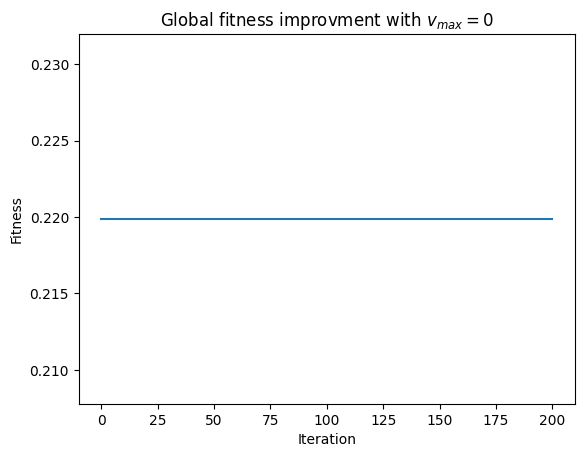

In [22]:
J_g, b_g, h_g, J_global = pso_NN(X, y_k, 50, 0)
plt.figure()
plt.plot(np.arange(len(J_global)), J_global)
plt.title("Global fitness improvment with $v_{max} = 0$")
plt.xlabel("Iteration")
plt.ylabel("Fitness")
plt.show()

In [ ]:
# Run algorithm 10 times, noting the prediction accuracy (or error) for each run 
# TODO
from joblib import Parallel, delayed

results = Parallel(n_jobs=-1, verbose=10)(delayed(lambda: pso_NN(X, y_k, 50, 0.1))()for _ in range(10))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed:   16.1s remaining:   37.6s
[Parallel(n_jobs=-1)]: Done   5 out of  10 | elapsed:   16.1s remaining:   16.1s
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:   16.1s remaining:    6.8s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   16.2s finished


In [43]:
accuracy = []
best_fitness = np.inf
J_sequence = []

for J_g, b_g, h_g, J_global in results:
    accuracy.append(pred_acc(h_g, X, y_k))
    if J_g < best_fitness:
        best_fitness = J_g
        J_sequence = J_global

In [44]:
# Plot the best_fitness of each run vs. the number of iterations it took (in case of stop condition #2)
# TODO

Prediction accuracy mean: 100.0%


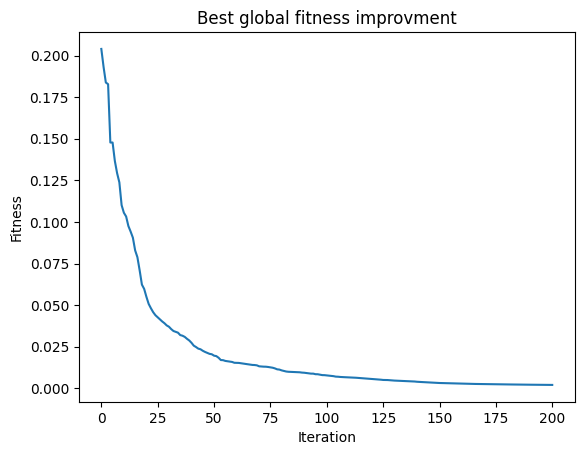

In [46]:
# For one of the 10 runs (choose the one with the best fitness), plot J(w1, w2) as a function of the iteration number
# TODO
print(f"Prediction accuracy mean: {np.round(np.mean(accuracy) * 100, 2)}%")
plt.figure()
plt.plot(np.arange(len(J_sequence)), J_sequence)
plt.title("Best global fitness improvment")
plt.xlabel("Iteration")
plt.ylabel("Fitness")
plt.show()



### Comment on your 

Here we can see on the plot that more iteration we have, more precise is the method.
The curve of the fitness improvement follow an exponential decay, meaning that first, iterations increase a lot the accuracy of the method, and then, adding some iterations will change nothing.
So the method converge very quickly to a good solution, which is really nice.
For instance, there is a very poor fitness improvement between 100 and 200 iterations compared to 0 to 100 iterations.
So only 100 iterations are usefull to have a very good solution and 50 to have a good enough solution.

This means that the number of iterations, like the number of particles, must be correctly defined in order to obtain satisfactory results without excessive computation time (balance between precision and computation).

If we look at the prediction accuracy mean, we can see that the mean is of 100%, that is very nice.
It means that the method is very accurate for the guided parameters chosen.
This also means that the guided parameters can be optimized to have good enough results without too big computation time.

Answer the following Questions: 

1.  Q: What is the Search Space of our problem?

    A: The search space of the PSO algorithm consists of all possible moves within the boundaries of the problem:
    we define some boundaries in each dimension to restrict moves of the particles inside a small region.
    As result, the search space is continuous.
    
    For $D$ dimensions, we can define the search space $S$ according to $lower\_bound, upper\_bound \in \mathbb{R}^D$ like this:

    $S = [lower\_bound, upper\_bound] \subset \mathbb{R}^D$


2.  Q: Explain the coefficients c1 & c2

    A: First, theses two coefficients appears in the formula bellow:
    $v_{i,t+1} = \omega v_{i,t} + c_1 r_1 (b_{i,t} - s_{i,t}) + c_2 r_2 (b_{G,t} - s_{i,t})$
    In this formula that define the velocity of the particle $i$ at iteration $t + 1$, we have:
    - $\omega v_{i,t}$ the inertia of the particle. So the particle that has moved to its position with a certain velocity will have a certain inertia and continue to move forward thanks to $\omega$.
    A small value of $\omega$ give a small inertia of the particle, so the particle will stop move fastly if it's not subject to any other influence.
    - $c_1 r_1 (b_{i,t} - s_{i,t})$ that is the attraction of the local best solution over the particle.
    As $r_1$ is chosen randomly, it means that $c_1$ control the influence of the local best solution over the particle.
    This parameter is called cognitive coefficient.
    It's as if this parameter controls the particle's memory, which remembers more or less well the best position it has passed through.
    Small values make small influence of the local best solution, unlike large values 
    - $c_2 r_2 (b_{G,t} - s_{i,t})$ that is the attraction of the global best solution over the particle.
    As $r_2$ is chosen randomly, it means that $c_2$ control the influence of the global best solution over the particle.
    This parameter is called the social coefficient.
    It's as if this parameter controls how other particles influence the current particle to join them because they are in a better position.
    Small values make small social influence over the given particle.
    

3.  Q: How is PSO similar to Ant Algorithm?

    A: First of all, PSO is a population-based metaheuristic algorithm, like Ant Algorithm because it generate at each iterations N possible solutions (thanks to the N particles), like Ant Algorithm.
    And this possible solutions are then used to generate new possibles solutions, both in PSO and in Ant Algorithm:
    - For PSO, each solution is represented by the position of a particle in the search space.
        So at the next iteration, the particle will move according to its current position and get a new solution at the end of its move. That's why previous solutions are used to build new solutions.
    - For Ant Algorithm, each ant leave some pheromones on the path chosen. Then, the ants will be guided by the pheromons left on path by previous ant, knowing that at each iteration, an ant build a solution.

    PSO have many variants, like for instance Firefly algorithm.
    In the same way, Ant Algorithm have also many variants, as for example the Ant Colony System algorithm.
